# Intertidal zone mapping with Sentinel-1

### Import required libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from odc.geo import BoundingBox
import odc.geo.xr
import pathlib
import xarray as xr
from scipy.ndimage import uniform_filter

from pystac_client import Client
from odc.stac import load, configure_s3_access
from dea_tools.dask import create_local_dask_cluster


# Adapted from https://stackoverflow.com/questions/39785970/speckle-lee-filter-in-python
def lee_filter(img, size):
    """
    Applies the Lee filter to reduce speckle noise in an image.

    Parameters:
    img (ndarray): Input image to be filtered.
    size (int): Size of the uniform filter window.

    Returns:
    ndarray: The filtered image.
    """
    img_mean = uniform_filter(img, size)
    img_sqr_mean = uniform_filter(img**2, size)
    img_variance = img_sqr_mean - img_mean**2

    overall_variance = np.nanvar(img)

    img_weights = img_variance / (img_variance + overall_variance)
    img_output = img_mean + img_weights * (img - img_mean)
    return img_output


# Define a function to apply the Lee filter to a DataArray
def apply_lee_filter(data_array, size=7):
    """
    Applies the Lee filter to the provided DataArray.

    Parameters:
    data_array (xarray.DataArray): The data array to be filtered.
    size (int): Size of the uniform filter window. Default is 7.

    Returns:
    xarray.DataArray: The filtered data array.
    """
    filtered_data = xr.apply_ufunc(
        lee_filter,
        data_array,
        kwargs={"size": size},
        input_core_dims=[["y", "x"]],
        output_core_dims=[["y", "x"]],
        dask_gufunc_kwargs={"allow_rechunk": True},
        vectorize=True,
        dask="parallelized",
        output_dtypes=[data_array.dtype],
    )
    return filtered_data

### Environment set up

In [2]:
catalog = "https://explorer.dev.dea.ga.gov.au/stac"
stac_client = Client.open(catalog)
configure_s3_access(cloud_defaults=True, aws_unsigned=True)
client = create_local_dask_cluster()


/env/lib/python3.10/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 44577 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/robbi.bishoptaylor@ga.gov.au/proxy/44577/status,
Dashboard: /user/robbi.bishoptaylor@ga.gov.au/proxy/44577/status,Workers: 1
Total threads: 62,Total memory: 456.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44691,Workers: 0
Dashboard: /user/robbi.bishoptaylor@ga.gov.au/proxy/44577/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:42967,Total threads: 62
Dashboard: /user/robbi.bishoptaylor@ga.gov.au/proxy/36441/status,Memory: 456.00 GiB
Nanny: tcp://127.0.0.1:45805,


## Set search parameters


In [3]:
# Collections to query
collections_to_search = ["ga_s1_nrb_iw_vv_vh_0"]

# Area of interest
aoi_bbox = BoundingBox(
    left=118.32,
    bottom=-20.40,
    right=118.63,
    top=-20.25,
    crs="EPSG:4326"
)

# Date range of interest
start_date = "2023"
end_date = "2025"

# Display the Area of Interest on a map
aoi_bbox.explore()

## Search and load

In [4]:
items = stac_client.search(
    collections=collections_to_search,
    datetime=f"{start_date}/{end_date}",
    intersects=aoi_bbox.boundary(),
).item_collection()

print(f"Found {len(items)} items")

Found 132 items


In [5]:
ds = load(
    items=items,
    bands=["VV_gamma0"],
    intersects=aoi_bbox.boundary(),
    crs="utm",
    resolution=20,
    groupby="solar_day",
    chunks={},
)

In [6]:
VV_gamma0_lee = apply_lee_filter(ds.VV_gamma0)
VV_gamma0_lee.load();

## Tide modelling

Calculate tides for each Sentinel-1 timestep using `eo-tides` [Python package](https://github.com/GeoscienceAustralia/eo-tides):

Setting tide modelling location from dataset centroid: 118.48, -20.33
Modelling tides with EOT20


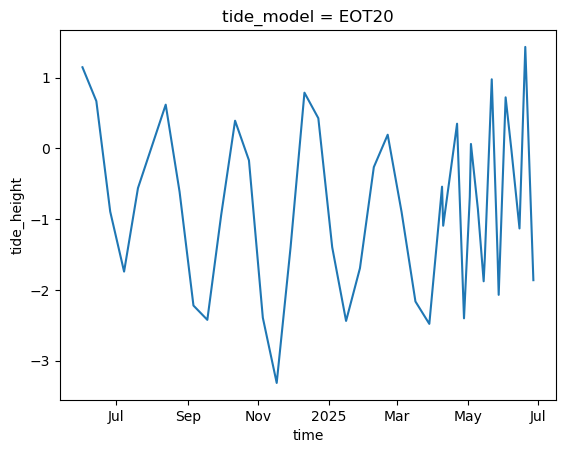

In [7]:
from eo_tides.eo import tag_tides

tides_da = tag_tides(VV_gamma0_lee, directory="/var/share/tide_models/")
tides_da.plot()

## Tide correlation

Calculate correlation between backscatter intensity and tide height, to identify pixels influenced by the tide:

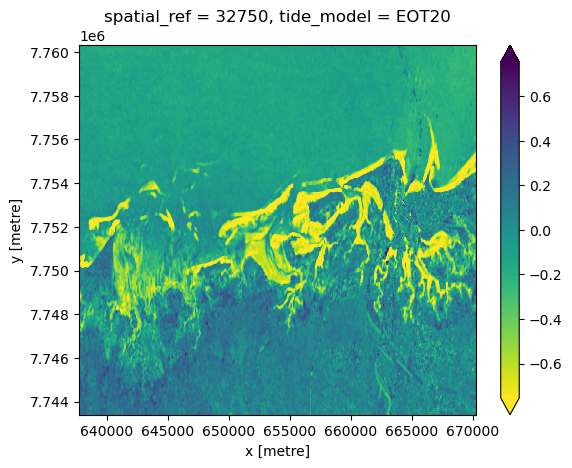

In [8]:
ds_corr = xr.corr(VV_gamma0_lee, tides_da, dim="time")
ds_corr.plot.imshow(cmap="viridis_r", robust=True)

In [9]:
# Threshold by correlation
ds_corr_thresh = ds_corr < -0.35

# Plot on a map
ds_corr_thresh.where(ds_corr_thresh).odc.explore(
    vmin=0,
    vmax=1,
    name="intertidal",
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri World Imagery",
)